## < Problem 1 >
![Problem 1](https://github.com/seoupark1/Stochastic-Control/blob/main/assets/images/kalman_filter/recursive_least_squares/recursive_ls_01.png?raw=true)

In [ ]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt

I = np.array([[0.2, 0.3, 0.4, 0.5, 0.6]]).T
V = np.array([[1.23, 1.38, 2.06, 2.47, 3.17]]).T

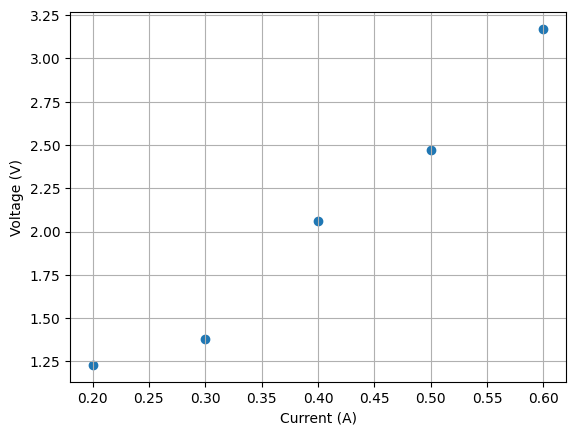

In [ ]:
plt.scatter(I, V)
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

## < Problem 2 >
![Problem 2](https://github.com/seoupark1/Stochastic-Control/blob/main/assets/images/kalman_filter/recursive_least_squares/recursive_ls_02.png?raw=true)

The slope and offset parameters of the best-fit line (i.e., the resistance and offset) are [R, b]:
4.970000000000002
0.07399999999999807


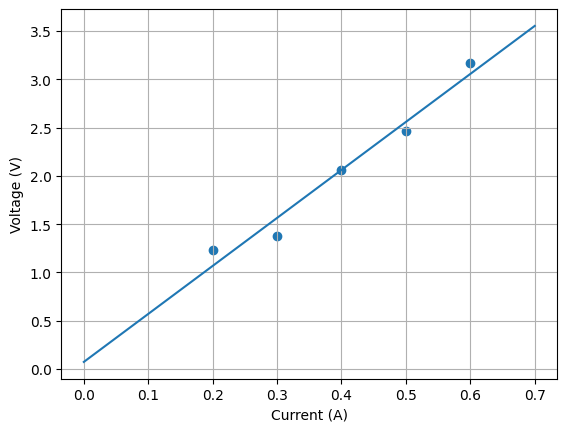

In [ ]:
## Batch Solution

H = np.ones((5, 2))
H[:, 0] = I.ravel()
x_ls = inv(H.T.dot(H)).dot(H.T.dot(V))
print('The slope and offset parameters of the best-fit line (i.e., the resistance and offset) are [R, b]:')
print(x_ls[0, 0])
print(x_ls[1, 0])

# Plot line.
I_line = np.arange(0, 0.8, 0.1).reshape(8, 1)
V_line = x_ls[0]*I_line + x_ls[1]

plt.scatter(I, V)
plt.plot(I_line, V_line)
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

## < Problem 3 >
![Problem 3](https://github.com/seoupark1/Stochastic-Control/blob/main/assets/images/kalman_filter/recursive_least_squares/recursive_ls_03.png?raw=true)

In [ ]:
## Recursive Solution

# Initialize the 2x1 parameter vector x (i.e., x_0).
x_k = np.array([[4, 0]]).T

#Initialize the 2x2 covaraince matrix (i.e. P_0). Off-diangonal elements should be zero.
P_k = np.array([[9.0, 0],
               [0, 0.2]])

# Our voltage measurement variance (denoted by R, don't confuse with resistance).
R_k = np.array([[0.0225]])

# Pre allocate space to save our estimates at every step.
num_meas = I.shape[0]
x_hist = np.zeros((num_meas + 1, 2))
P_hist = np.zeros((num_meas + 1, 2, 2))

x_hist[0] = x_k.ravel()
P_hist[0] = P_k

# Iterate over all the available measurements.
for k in range(num_meas):
    # Construct H_k (Jacobian).
    H_k = np.array([[I[k, 0], 1]])

    # Construct K_k (gain matrix).
    K_k = P_k @ H_k.T @ inv(H_k @ P_k @ H_k.T + R_k)

    # Update our estimate.
    x_k = x_k + K_k @ (V[k] - H_k @ x_k)

    # Update our uncertainty (covariance)
    P_k = (np.eye(2) - K_k @ H_k) @ P_k

    # Keep track of our history.
    P_hist[k + 1] = P_k
    x_hist[k + 1] = x_k.ravel()

print('The slope and offset parameters of the best-fit line (i.e., the resistance and offset) are [R, b]:')
print(x_k[0, 0])
print(x_k[1, 0])

The slope and offset parameters of the best-fit line (i.e., the resistance and offset) are [R, b]:
4.976925034352893
0.06966257824825736


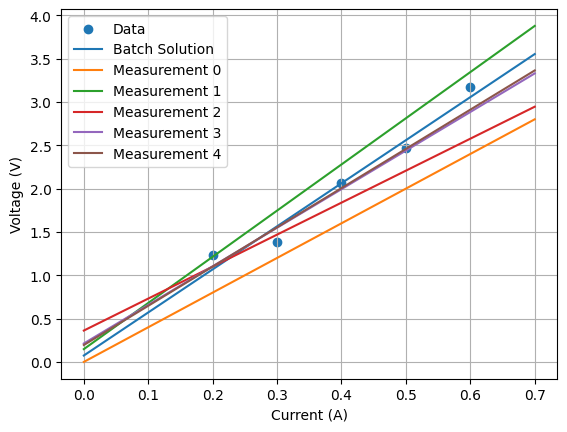

In [ ]:
plt.scatter(I, V, label='Data')
plt.plot(I_line, V_line, label='Batch Solution')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')
plt.grid(True)

I_line = np.arange(0, 0.8, 0.1).reshape(8, 1)

for k in range(num_meas):
    V_line = x_hist[k, 0]*I_line + x_hist[k, 1]
    plt.plot(I_line, V_line, label='Measurement {}'.format(k))

plt.legend()
plt.show()